## Математическая статистика для анализа больших данных

### Семинар 12

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as sps

import matplotlib.pyplot as plt
import seaborn as sns

from tqdm import tqdm

import warnings

sns.set(palette='Set2')
warnings.filterwarnings('ignore')

%matplotlib inline

## Задача 1

Рассмотрим схему испытаний Бернулли (т.е. броски монет) с вероятностью успеха $\theta$.


**1)** Сгенерируйте выборку размера 15 из бернуллиевского распределения:

In [2]:
true_theta = 0.3
sample = sps.bernoulli(p=true_theta).rvs(size=15)

Выберите параметры априорного распределения:

In [3]:
a_prior = 9
b_prior = 9

Рассчитайте параметры апостериорного распределения:

In [4]:
def bern_posterior_params(sample, a, b):
    '''Находит параметры апостериорного распределения

    :param sample: выборка
    :param a: параметр alpha априорного распределения
    :param b: параметр beta априорного распределения

    :returns: параметры апостериорного
    '''

    return a + np.sum(sample), b + len(sample) - np.sum(sample)

In [5]:
a_post, b_post = bern_posterior_params(sample, a_prior, b_prior)
a_post, b_post

(15, 18)

In [6]:
posterior_distr = sps.beta(a=a_post, b=b_post)

Нарисуйте на одном графике априорную и полученную апостериорную плотности. Отметьте истинное значение $\theta$, а также математическое ожидание и моду апостериорного распределения:

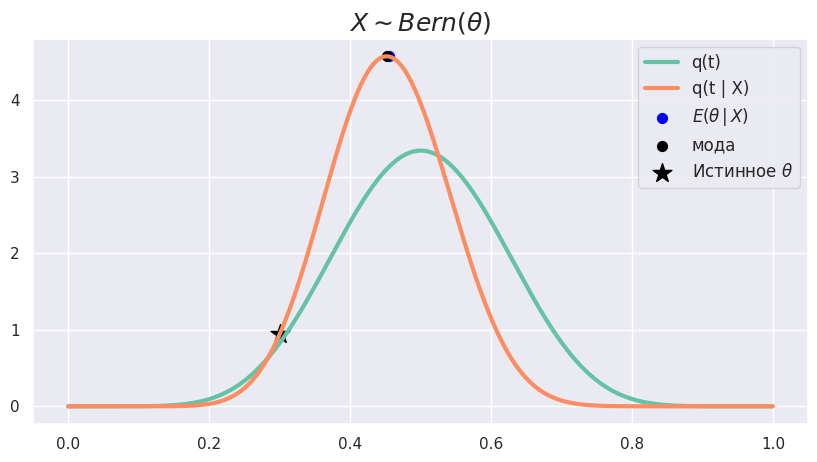

In [7]:
step = 0.001
grid = np.arange(0, 1, step)

plt.figure(figsize=(10, 5))
plt.title(r'$X \sim Bern(\theta)$', fontsize=18)

plt.plot(grid, sps.beta(a=a_prior, b=b_prior).pdf(grid), lw=3, label='q(t)')
plt.plot(grid, posterior_distr.pdf(grid), lw=3, label='q(t | X)')

mean = a_post / (a_post + b_post)
mode = (a_post - 1) / (a_post + b_post - 2)
plt.scatter(mean, posterior_distr.pdf(mean), s=50, color='blue', label=r'$E(\theta\,|\,X)$')
plt.scatter(mode, posterior_distr.pdf(mode), s=50, color='black', label=r'мода')

plt.scatter(true_theta, posterior_distr.pdf(true_theta),
            s=200, color='black', marker='*', label=r'Истинное $\theta$')

plt.legend(fontsize=12)

plt.show()

Для апостериорного распределения рассчитайте какой-нибудь доверительный интервал уровня доверия 0.95. Например, в качестве границ интервала можно рассмотреть квантили распределения. Попало ли истинное значение параметра в интервал?

In [8]:
alpha = 0.05 # alpha vs. 1 - alpha
sps.beta(a=a_post, b=b_post).ppf((alpha / 2, 1 - alpha / 2))

array([0.29093982, 0.62337427])

Найдите апостериорные вероятности $P(\theta > 0.5\,|\,X)$ и $P(\theta \leqslant 0.3\,|\,X)$:

In [9]:
posterior_distr.sf(0.5), posterior_distr.cdf(0.3)

(0.29830744792707264, 0.03272365809025799)

**2)** Постройте несколько графиков сопряженного распределения для разных параметров и охарактеризуйте, как его значения параметров соотносятся с априорными знаниями о монете.
Можно рассмотреть следующие случаи.
* Монета скорее честная. Тогда наиболее вероятны значения $\theta$ в окрестности $0.5$.
* Монета скорее нечестная, перевес неизвестен. Тогда наименее вероятны значения $\theta$ в окрестности $0.5$.
* Монета скорее нечестная, перевес в сторону герба. Тогда наиболее вероятны значения $\theta$ в окрестности $1$.
* Монета скорее честная, либо с небольшим перекосом вправо. Тогда наиболее вероятны значения $\theta$ в окрестности $\approx 0.6$.
* Ничего не известно. Тогда все значения равновероятны.

Для каждого случая из перечисленных выше постройте график плотности сопряженного распределения (на одной фигуре).

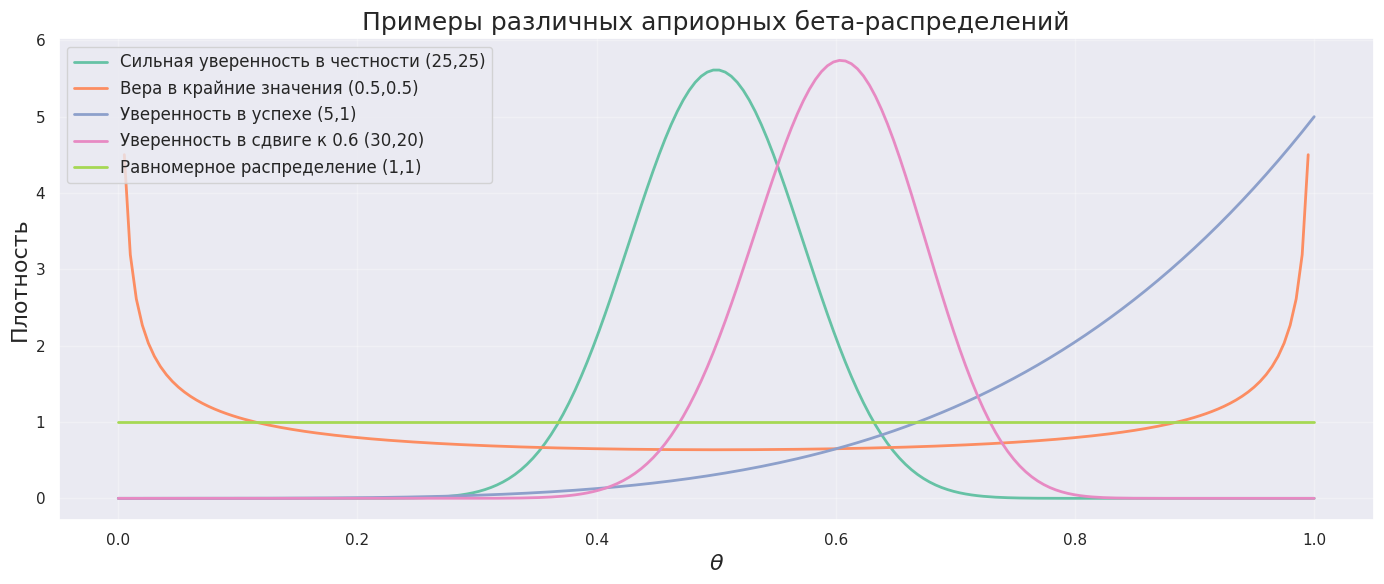

In [29]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta

grid = np.linspace(0, 1, 200)

dist1 = beta(25, 25)
dist2 = beta(0.5, 0.5)
dist3 = beta(5, 1)
dist4 = beta(30, 20)
dist5 = beta(1, 1)

plt.figure(figsize=(14, 6))
plt.plot(grid, dist1.pdf(grid), label='Сильная уверенность в честности (25,25)', linewidth=2)
plt.plot(grid, dist2.pdf(grid), label='Вера в крайние значения (0.5,0.5)', linewidth=2)
plt.plot(grid, dist3.pdf(grid), label='Уверенность в успехе (5,1)', linewidth=2)
plt.plot(grid, dist4.pdf(grid), label='Уверенность в сдвиге к 0.6 (30,20)', linewidth=2)
plt.plot(grid, dist5.pdf(grid), label='Равномерное распределение (1,1)', linewidth=2)

plt.title('Примеры различных априорных бета-распределений', fontsize=18)
plt.xlabel(r'$\theta$', fontsize=16)
plt.ylabel('Плотность', fontsize=16)
plt.grid(alpha=0.3)
plt.legend(fontsize=12, loc='upper left')
plt.tight_layout()
plt.show()


---
*Решение:*

Сопряженным распределением в данном случае будет являться $\theta \sim \ (a,b).$.

Тогда $\theta | X \sim \; Beta(a+∑X,b+n−∑X)$.

Если мы рассматриваем семейство бета-распределений $Beta(α, β)$, то выбор значений параметров $α$ и $β$ существенно влияет на форму плотности распределения:

Когда $α$ и $β$ большие 1:
При увеличении обоих параметров распределение становится более «острым» и сконцентрированным вокруг своей моды. Кривая плотности при этом «вытягивается» вверх и становится более узкой. Чем больше значения $α$ и $β$, тем сильнее выражена «уверенность» в том, что истинное значение $θ$ сосредоточено в окрестности некоторой точки (моды).

Когда $α$ и/или $β$ меньше $1$:
Если параметры меньше единицы, плотность, наоборот, стремится к краям интервала $[0,1]$.

Например:
При $α < 1$ и $β < 1$ плотность может иметь «U»-образную форму, делая экстремальные значения $θ ≈ 0$ или $θ ≈ 1$ более вероятными, чем значения около $0.5$. Это отражает большую неопределённость или склонность к крайним гипотезам.

Равномерное распределение $(α = 1, β = 1)$:
Когда $α = β = 1$, бета-распределение сводится к равномерному, то есть нет никакого априорного предпочтения ни к одной части интервала.


---

Реализуйте функцию, вычисляющую параметры апостериорного распределения:

In [31]:
def bern_posterior_params(sample, a, b):
    '''Находит параметры апостериорного распределения

    :param sample: выборка
    :param a: параметр alpha априорного распределения
    :param b: параметр beta априорного распределения

    :returns: параметры апостериорного
    '''

    return a + np.sum(sample), b + len(sample) - np.sum(sample)

**3)** Проведите 15 бросков симметричной монеты и рассмотрите случаи различных априорных распределений, заданных в пункте 2). Визуализируйте для каждого случая априорное и апостериорное распределения. Отметьте на графике также истинное значение рассматриваемого параметра.

In [39]:
# генерация выборки

size = 15
p = 0.5
sample_sym = sps.bernoulli(p).rvs(size)

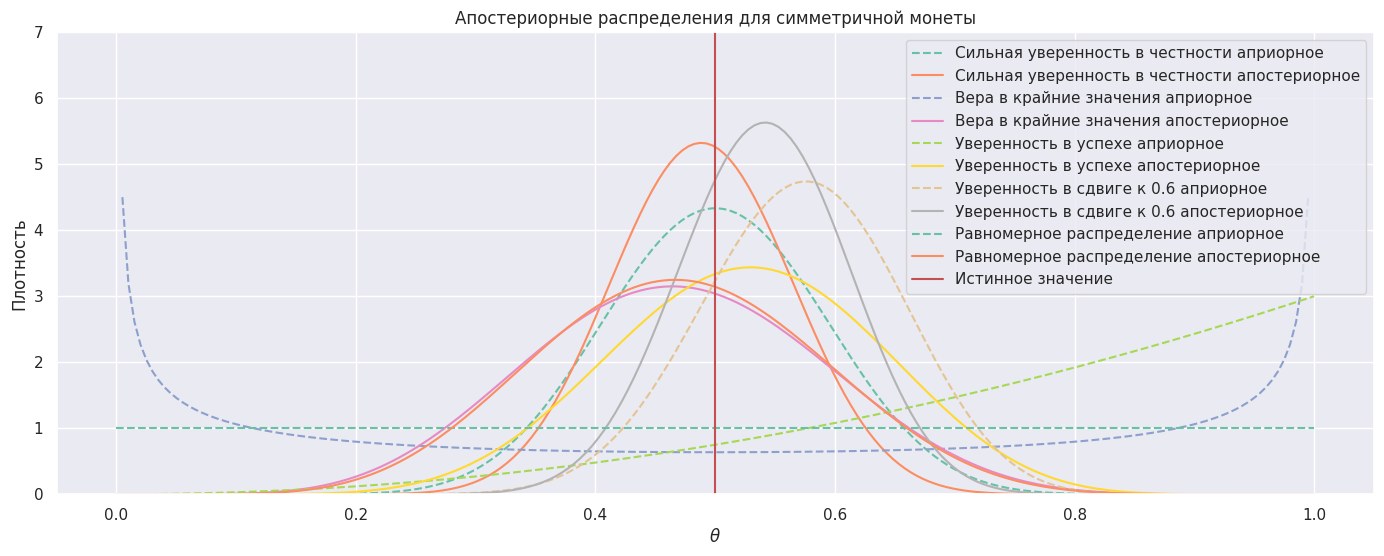

In [56]:
priors = [
    ("Сильная уверенность в честности", 15, 15),
    ("Вера в крайние значения", 0.5, 0.5),
    ("Уверенность в успехе", 3, 1),
    ("Уверенность в сдвиге к 0.6", 20, 15),
    ("Равномерное распределение", 1, 1)
]

size = 15

p_sym = 0.5
sample_sym = sps.bernoulli(p_sym).rvs(size)
grid = np.linspace(0, 1, 200)

plt.figure(figsize=(17, 6))
for name, a_prior, b_prior in priors:
    a_post, b_post = bern_posterior_params(sample_sym, a_prior, b_prior)
    prior = sps.beta(a_prior, b_prior)
    posterior = sps.beta(a_post, b_post)
    plt.plot(grid, prior.pdf(grid), '--', label=f'{name} априорное')
    plt.plot(grid, posterior.pdf(grid), label=f'{name} апостериорное')

plt.axvline(x=p_sym, color='r', linestyle='-', label='Истинное значение')

plt.ylim(0, 7)
plt.title('Апостериорные распределения для симметричной монеты')
plt.xlabel(r'$\theta$')
plt.ylabel('Плотность')
plt.legend()
plt.show()

**4)** Проведите аналогичный эксперимент для несимметричной монеты. Сравните полученные апостериорные распределения с апостериорными распределениями в симметричном случае

In [49]:
# несимметричный случай, перевес в сторону орла (0)

size = 15
p = 0.05
sample_nonsym = sps.bernoulli(p).rvs(size)

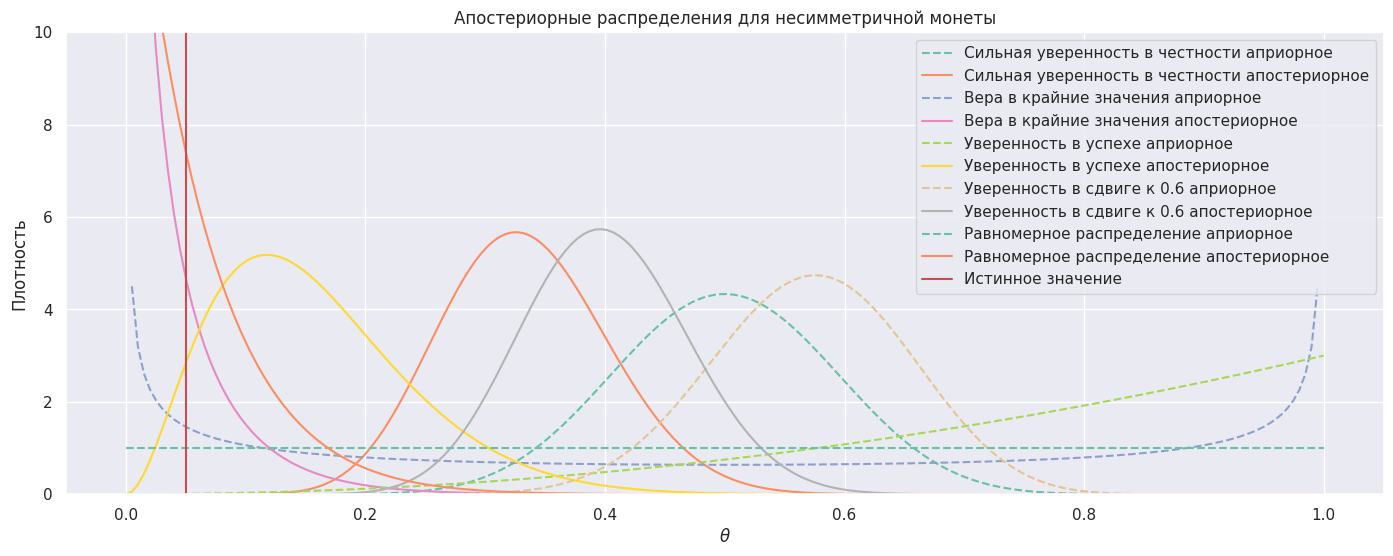

In [58]:
p_nonsym = 0.05
sample_nonsym = sps.bernoulli(p_nonsym).rvs(size)

plt.figure(figsize=(17, 6))
for name, a_prior, b_prior in priors:
    a_post, b_post = bern_posterior_params(sample_nonsym, a_prior, b_prior)
    prior = sps.beta(a_prior, b_prior)
    posterior = sps.beta(a_post, b_post)
    plt.plot(grid, prior.pdf(grid), '--', label=f'{name} априорное')
    plt.plot(grid, posterior.pdf(grid), label=f'{name} апостериорное')

plt.axvline(x=p_nonsym, color='r', linestyle='-', label='Истинное значение')


plt.ylim(0, 10)
plt.title('Апостериорные распределения для несимметричной монеты')
plt.xlabel(r'$\theta$')
plt.ylabel('Плотность')
plt.legend()
plt.show()